In [2]:
#数据集的处理
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv("abalone.csv")
data.head()


,Sex,Length,Diameter,Height,Wholeweight,Shuckedweight,Visceraweight,Shellweight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


# 数据预处理

In [4]:
# Choose Important Features 
#为每个类别创造新的二元列
sex_encode=pd.get_dummies(data['Sex']).astype(int)
#先转化成True/False,再换到1/0。
print(sex_encode.head())

   F  I  M
0  0  0  1
1  0  0  1
2  1  0  0
3  0  0  1
4  0  1  0


In [5]:
#加到原来的表里面去，把原先的sex列给替换掉.
abalone_df=data.drop('Sex',axis=1)
abalone_df=pd.concat([sex_encode,abalone_df],axis=1)

In [6]:
abalone_df['Age']=abalone_df['Rings']+1.5
abalone_df=abalone_df.drop('Rings',axis=1)
print(abalone_df.head())

   F  I  M  Length  Diameter  Height  Wholeweight  Shuckedweight  \
0  0  0  1   0.455     0.365   0.095       0.5140         0.2245   
1  0  0  1   0.350     0.265   0.090       0.2255         0.0995   
2  1  0  0   0.530     0.420   0.135       0.6770         0.2565   
3  0  0  1   0.440     0.365   0.125       0.5160         0.2155   
4  0  1  0   0.330     0.255   0.080       0.2050         0.0895   

   Visceraweight  Shellweight   Age  
0         0.1010        0.150  16.5  
1         0.0485        0.070   8.5  
2         0.1415        0.210  10.5  
3         0.1140        0.155  11.5  
4         0.0395        0.055   8.5  


In [7]:
#计算皮尔逊相关系数来选取特征列
abalone_corr=abs(abalone_df.corr())
abalone_corr=abalone_corr.round(2)
abalone_corr.head(11)

,F,I,M,Length,Diameter,Height,Wholeweight,Shuckedweight,Visceraweight,Shellweight,Age
F,1.00,0.46,0.51,0.31,0.32,0.30,0.30,0.26,0.31,0.31,0.25
I,0.46,1.00,0.52,0.55,0.56,0.52,0.56,0.52,0.56,0.55,0.44
M,0.51,0.52,1.00,0.24,0.24,0.22,0.25,0.25,0.24,0.24,0.18
Length,0.31,0.55,0.24,1.00,0.99,0.83,0.93,0.90,0.90,0.90,0.56
Diameter,0.32,0.56,0.24,0.99,1.00,0.83,0.93,0.89,0.90,0.91,0.57
Height,0.30,0.52,0.22,0.83,0.83,1.00,0.82,0.77,0.80,0.82,0.56
Wholeweight,0.30,0.56,0.25,0.93,0.93,0.82,1.00,0.97,0.97,0.96,0.54
Shuckedweight,0.26,0.52,0.25,0.90,0.89,0.77,0.97,1.00,0.93,0.88,0.42
Visceraweight,0.31,0.56,0.24,0.90,0.90,0.80,0.97,0.93,1.00,0.91,0.50
Shellweight,0.31,0.55,0.24,0.90,0.91,0.82,0.96,0.88,0.91,1.00,0.63


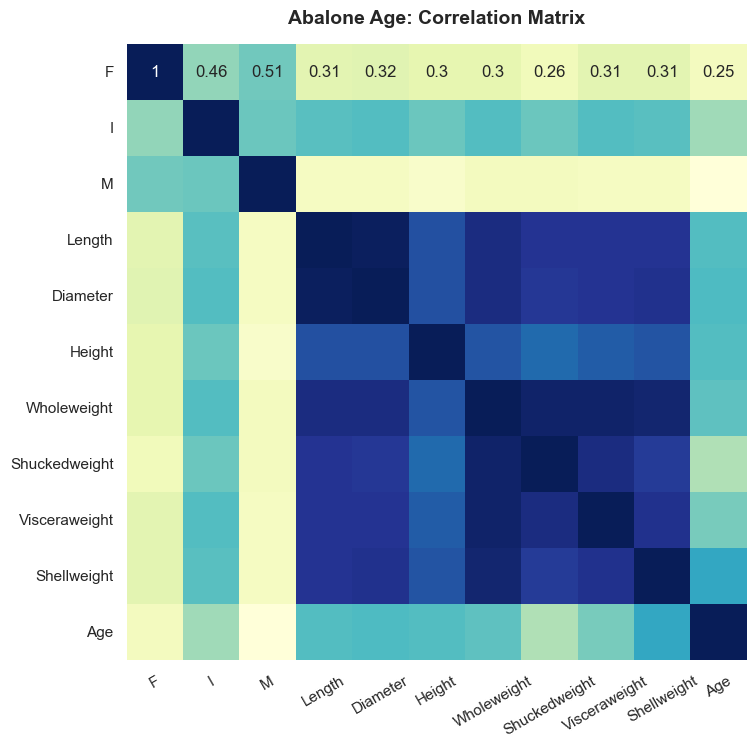

In [8]:
sns.set(rc={'figure.figsize':(8,8)})

# Visually display the matrix from above
# use the yellow-green-blue color map so that high correlations are more easily identifiable
h = sns.heatmap(abalone_corr, annot=True, cmap="YlGnBu", cbar=False)

# Add plot title 
h.set_title('Abalone Age: Correlation Matrix', size=14, weight='bold', pad=15)

# rotate tick marks so they are easier to read
plt.xticks(rotation=30)

# Display plot
plt.show()

In [17]:
#观察后发现
#diameter length有着多重共线性，再抛掉wholeweight,因为它和shuckedweight,visceraweight,shellweight有多重共线性
abalone_df=abalone_df.drop(['Diameter','Wholeweight'],axis=1)
print(abalone_df.head())
print(abalone_df.shape)

   F  I  M  Length  Height  Shuckedweight  Visceraweight  Shellweight   Age
0  0  0  1   0.455   0.095         0.2245         0.1010        0.150  16.5
1  0  0  1   0.350   0.090         0.0995         0.0485        0.070   8.5
2  1  0  0   0.530   0.135         0.2565         0.1415        0.210  10.5
3  0  0  1   0.440   0.125         0.2155         0.1140        0.155  11.5
4  0  1  0   0.330   0.080         0.0895         0.0395        0.055   8.5
(4177, 9)


# Creat Dataset and Split

In [43]:
#接下来要分割数据集了，首先分离标签和训练数据
features_df=abalone_df.iloc[:,:8]
label_df=abalone_df.iloc[:,8]

from torch.utils.data import TensorDataset, DataLoader, random_split

# 将 pandas DataFrame 转换为 Tensor 类型
features=torch.tensor(features_df.values, dtype=torch.float32)
label=torch.tensor(label_df.values, dtype=torch.float32)

dataset=TensorDataset(features, label)

# 将数据集划分为训练集和测试集
train_len=int(len(dataset)*0.7)
test_len=len(dataset)-train_len

train_dataset, test_dataset = random_split(dataset, [train_len, test_len])

# 定义小批量的大小
batch_size = 32

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

#print(next(iter(train_loader)))可以打印出来看看
# 获取一个批次的数据
batch_data = next(iter(train_loader))

# 查看数据类型
print(type(batch_data[0]), type(batch_data[1]))

# 查看数据形状
print(batch_data[0].shape, batch_data[1].shape)

<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([32, 8]) torch.Size([32])


In [49]:
# 设定每个隐藏层的神经元数量
hidden_size1 = 100
hidden_size2 = 100

# 定义神经网络结构
class Net(nn.Module):
    def __init__(self,activation='relu'):
        super(Net, self).__init__()
        self.activation=activation
        # 输入层到隐藏层，8个特征输入，hidden_size1个输出
        self.fc1 = nn.Linear(8, hidden_size1)
        # 隐藏层到隐藏层，hidden_size1个输入，hidden_size2个输出
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        # 隐藏层到输出层，hidden_size2个输入，1个输出（预测的年龄）
        self.fc3 = nn.Linear(hidden_size2, 1)

    def forward(self, x):
        if self.activation=='relu':
            # 使用ReLU激活函数
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            # 对最后一层不使用激活函数，因为我们的任务是回归，需要输出实数
            x = self.fc3(x)
            return x
        elif self.activation=='sigmoid':
            x = torch.sigmoid(self.fc1(x))
            x = torch.sigmoid(self.fc2(x))
            # 对最后一层不使用激活函数，因为我们的任务是回归，需要输出实数
            x = self.fc3(x)
            return x


In [57]:
#定义训练损失函数
net=Net()
lr=0.02
loss_fn=nn.MSELoss()
batch_size=32
optimizer = torch.optim.SGD(net.parameters(), lr=lr)
# 列出网络中所有的可以优化的参数
# for name, param in net.named_parameters():
#     if param.requires_grad:
#         print(name, param.data)
num_epochs=40
#转移到GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#定义验证损失函数
def validate(model, criterion, val_loader):
    model.eval()  # 设置模型为评估模式
    total_val_loss = 0
    with torch.no_grad():  # 不需要计算梯度，也不会进行反向传播
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)  # 如果使用 GPU，将数据移到 GPU
            outputs = model(inputs)  # 前向传播计算模型的预测值
            loss = criterion(outputs, targets.reshape(-1,1))  # 计算损失
            total_val_loss += loss.item()  # 累计损失

    average_val_loss = total_val_loss / len(val_loader)  # 计算平均损失
    return average_val_loss
def validate_and_calculate_MAE(model, val_loader):
    model.eval()
    total_val_loss = 0
    total_abs_error = 0
    count = 0   # 计算总的样本数，用于最后的平均
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            abs_error = torch.abs(outputs - targets.reshape(-1,1)) # 计算 |预测-实际|
            total_abs_error += torch.sum(abs_error).item() # 累加
            count += inputs.size(0) # 累加样本数
    average_MAE = total_abs_error / count # 最终的 MAE
    return average_MAE
losses = []


from torch.optim import lr_scheduler
# 初始化 optimizer
#optimizer = torch.optim.SGD(net.parameters(), lr=0.02, momentum=0.9)

# 设置 scheduler
#scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

for epoch in range(num_epochs):
    epoch_loss = 0
    for i, (inputs, targets) in enumerate(train_loader):
        # clear previous gradients
        optimizer.zero_grad()
        # forward pass
        outputs = net(inputs)
        # calculate loss
        loss = loss_fn(outputs, targets.reshape(-1,1))
        # backward pass
        loss.backward()
        # update weights
        optimizer.step()   
        # 累积每一个批次的训练损失
        epoch_loss += loss.item()
        #验证过程——MAE
        val_loss=validate_and_calculate_MAE(net,test_loader)
        #val_loss=validate(net,loss_fn,test_loader)
        # 如果验证损失在一段时间内没有下降，scheduler 会减少 learning rate
        #scheduler.step(val_loss)
    # 每一个epoch结束后，计算平均损失并记录
    epoch_loss /= len(train_loader) 
    print('Epoch [{}/{}], train_Loss: {:.4f}，val_Loss: {:.4f}'.format(epoch+1, num_epochs, epoch_loss,val_loss))
    losses.append(epoch_loss)


Epoch [1/40], train_Loss: 18.1995，val_Loss: 1.8259
Epoch [2/40], train_Loss: 7.9195，val_Loss: 1.8764
Epoch [3/40], train_Loss: 7.0748，val_Loss: 2.3474
Epoch [4/40], train_Loss: 6.7040，val_Loss: 1.9905
Epoch [5/40], train_Loss: 6.2785，val_Loss: 1.8205
Epoch [6/40], train_Loss: 6.1875，val_Loss: 2.0404
Epoch [7/40], train_Loss: 5.7654，val_Loss: 1.6477
Epoch [8/40], train_Loss: 6.1502，val_Loss: 1.6242
Epoch [9/40], train_Loss: 5.4025，val_Loss: 1.5980
Epoch [10/40], train_Loss: 5.6105，val_Loss: 1.6002
Epoch [11/40], train_Loss: 5.2313，val_Loss: 2.2141
Epoch [12/40], train_Loss: 5.3997，val_Loss: 1.5925
Epoch [13/40], train_Loss: 5.3069，val_Loss: 1.6755
Epoch [14/40], train_Loss: 5.3100，val_Loss: 1.8006
Epoch [15/40], train_Loss: 5.1775，val_Loss: 1.5573
Epoch [16/40], train_Loss: 5.2828，val_Loss: 1.7200
Epoch [17/40], train_Loss: 5.1868，val_Loss: 1.6811
Epoch [18/40], train_Loss: 5.3318，val_Loss: 1.5743
Epoch [19/40], train_Loss: 5.1880，val_Loss: 2.1036
Epoch [20/40], train_Loss: 5.2182，val_L